
# Grid-Aware Emergency Resource Allocation

The prototype uses four feeder groups and a synthetic road network. It is designed to demonstrate the architecture, not quantum advantage.


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from itertools import product
from scipy.optimize import minimize

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

try:
    from qiskit.circuit.library import QAOAAnsatz
    from qiskit.quantum_info import SparsePauliOp, Statevector
    from qiskit.primitives import StatevectorEstimator, StatevectorSampler
    QISKIT_AVAILABLE = True
except ImportError:
    QISKIT_AVAILABLE = False

np.set_printoptions(precision=4, suppress=True)


## 1. Define the grid and road network

In [3]:
feeders = ["A", "B", "C", "D"]
load_mw = np.array([30.0, 40.0, 25.0, 20.0])
critical = np.array([0.0, 0.0, 1.0, 0.0])
target_mw = 50.0
conflicts = [(0, 1)]

road = nx.Graph()
road_edges = [
    ("Depot", "J1", 3.0, "A"),
    ("Depot", "J2", 4.0, "C"),
    ("J1", "Scene", 4.0, "B"),
    ("J2", "Scene", 5.0, "A"),
    ("J1", "J2", 2.0, "A"),
    ("Scene", "J3", 3.0, "D"),
    ("Scene", "J4", 4.0, "C"),
    ("J3", "Hospital", 4.0, "B"),
    ("J4", "Hospital", 5.0, "A"),
    ("J3", "J4", 2.0, "C"),
]

for u, v, base_time, feeder in road_edges:
    road.add_edge(u, v, base_time=base_time, feeder=feeder)

road_positions = {
    "Depot": (-3.0, 0.0),
    "J1": (-1.8, 1.0),
    "J2": (-1.8, -1.0),
    "Scene": (0.0, 0.0),
    "J3": (1.8, 1.0),
    "J4": (1.8, -1.0),
    "Hospital": (3.2, 0.0),
}


## 2. Road degradation and ambulance routing

In [4]:
def build_scenario_graph(shed_set=None, degradation_multiplier=2.0, traffic_factor=1.0, backup_health=0.0):
    shed_set = shed_set or set()
    graph = road.copy()
    effective_multiplier = 1 + (degradation_multiplier - 1) * (1 - backup_health)

    for u, v, data in graph.edges(data=True):
        multiplier = effective_multiplier if data["feeder"] in shed_set else 1.0
        data["travel_time"] = data["base_time"] * traffic_factor * multiplier
        data["degraded"] = data["feeder"] in shed_set

    return graph

def path_time(graph, path):
    return sum(graph[u][v]["travel_time"] for u, v in zip(path[:-1], path[1:]))

def ambulance_route(graph):
    response_path = nx.shortest_path(graph, "Depot", "Scene", weight="travel_time")
    transport_path = nx.shortest_path(graph, "Scene", "Hospital", weight="travel_time")
    response_time = path_time(graph, response_path)
    transport_time = path_time(graph, transport_path)

    return {
        "response_path": response_path,
        "transport_path": transport_path,
        "full_path": response_path + transport_path[1:],
        "response_time": response_time,
        "transport_time": transport_time,
        "total_time": response_time + transport_time,
    }

baseline_graph = build_scenario_graph()
baseline_route = ambulance_route(baseline_graph)

print("Baseline emergency journey:", baseline_route["total_time"], "min")


Baseline emergency journey: 14.0 min


## 3. Build feeder features for the ML risk surrogate

In [5]:
baseline_route_edges = {
    tuple(sorted(edge))
    for edge in zip(
        baseline_route["full_path"][:-1],
        baseline_route["full_path"][1:]
    )
}

edge_betweenness = nx.edge_betweenness_centrality(
    road, weight="base_time"
)

def feeder_static_features(feeder):
    feeder_edges = [
        (u, v, data)
        for u, v, data in road.edges(data=True)
        if data["feeder"] == feeder
    ]

    affected_edge_count = len(feeder_edges)
    affected_base_time = sum(data["base_time"] for _, _, data in feeder_edges)
    baseline_route_overlap = sum(
        tuple(sorted((u, v))) in baseline_route_edges
        for u, v, _ in feeder_edges
    )

    centralities = [
        edge_betweenness.get((u, v), edge_betweenness.get((v, u), 0))
        for u, v, _ in feeder_edges
    ]

    return {
        "affected_edge_count": affected_edge_count,
        "affected_base_time": affected_base_time,
        "baseline_route_overlap": baseline_route_overlap,
        "mean_edge_betweenness": float(np.mean(centralities))
    }


## 4. Generate synthetic historical outage data

In [6]:
rng = np.random.default_rng(42)

training_rows = []

for _ in range(800):
    feeder = rng.choice(feeders)
    degradation_multiplier = rng.uniform(1.2, 3.0)
    traffic_factor = rng.uniform(0.8, 1.4)
    backup_health = rng.uniform(0.0, 0.9)

    baseline_scenario = build_scenario_graph(shed_set=set(), traffic_factor=traffic_factor)
    outage_scenario = build_scenario_graph(
        shed_set={feeder},
        degradation_multiplier=degradation_multiplier,
        traffic_factor=traffic_factor,
        backup_health=backup_health
    )

    baseline_time = ambulance_route(baseline_scenario)["total_time"]
    outage_time = ambulance_route(outage_scenario)["total_time"]
    delay = max(0.0, outage_time - baseline_time)

    training_rows.append({
        "feeder": feeder,
        **feeder_static_features(feeder),
        "degradation_multiplier": degradation_multiplier,
        "traffic_factor": traffic_factor,
        "backup_health": backup_health,
        "added_delay_min": delay
    })

training_data = pd.DataFrame(training_rows)
training_data.head()


,feeder,affected_edge_count,affected_base_time,baseline_route_overlap,mean_edge_betweenness,degradation_multiplier,traffic_factor,backup_health,added_delay_min
0,A,4,15.0,1,0.130952,1.989981,1.315159,0.627631,1.454453
1,D,1,3.0,1,0.380952,1.369519,1.385373,0.685026,0.483727
2,C,3,10.0,0,0.095238,1.430605,1.070232,0.333718,0.000000
3,D,1,3.0,1,0.380952,2.868177,1.186319,0.740485,1.725450
4,C,3,10.0,0,0.095238,1.609030,1.132751,0.057436,0.000000


## 5. Train the classical ML risk surrogate

In [7]:
feature_columns = [
    "affected_edge_count",
    "affected_base_time",
    "baseline_route_overlap",
    "mean_edge_betweenness",
    "degradation_multiplier",
    "traffic_factor",
    "backup_health"
]

X = training_data[feature_columns]
y = training_data["added_delay_min"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

risk_model = RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42)
risk_model.fit(X_train, y_train)

test_predictions = risk_model.predict(X_test)

mae = mean_absolute_error(y_test, test_predictions)
r2 = r2_score(y_test, test_predictions)

print(f"Risk surrogate MAE: {mae:.3f} min")
print(f"Risk surrogate R²: {r2:.3f}")


Risk surrogate MAE: 0.153 min
Risk surrogate R²: 0.971


## 6. Predict feeder risk for the current grid state

In [8]:
current_degradation = 2.0
current_traffic = 1.0
current_backup_health = 0.0

current_rows = [
    {
        "feeder": feeder,
        **feeder_static_features(feeder),
        "degradation_multiplier": current_degradation,
        "traffic_factor": current_traffic,
        "backup_health": current_backup_health,
    }
    for feeder in feeders
]

current_state = pd.DataFrame(current_rows)
predicted_risk = risk_model.predict(current_state[feature_columns])
current_state["predicted_risk_min"] = predicted_risk

current_state[["feeder", "predicted_risk_min"]]


,feeder,predicted_risk_min
0,A,2.908767
1,B,3.984049
2,C,0.000000
3,D,2.031100


## 7. Construct the ML-informed feeder-shedding QUBO

In [9]:
A_target = 0.05
B_critical = 20.0
C_conflict = 20.0
E_risk = 1.0

num_qubits = len(feeders)

def selected(x):
    names = [feeder for feeder, bit in zip(feeders, x) if bit]
    return ", ".join(names) if names else "None"

def shed_load(x):
    return float(load_mw @ np.asarray(x))

def coupled_objective(x):
    x = np.asarray(x, dtype=float)
    target_term = A_target * (load_mw @ x - target_mw) ** 2
    critical_term = B_critical * (critical @ x)
    conflict_term = C_conflict * sum(x[i] * x[j] for i, j in conflicts)
    risk_term = E_risk * (predicted_risk @ x)
    return float(target_term + critical_term + conflict_term + risk_term)

allocations = list(product([0, 1], repeat=num_qubits))
exact_solution = min(allocations, key=coupled_objective)
exact_energy = coupled_objective(exact_solution)

print("Exact classical optimum:", selected(exact_solution))
print("Load shed:", shed_load(exact_solution), "MW")
print("Objective:", exact_energy)


Exact classical optimum: A, D
Load shed: 50.0 MW
Objective: 4.9398673696471285


In [10]:
linear = (
    A_target * (load_mw**2 - 2 * target_mw * load_mw)
    + B_critical * critical
    + E_risk * predicted_risk
)

quadratic = np.zeros((num_qubits, num_qubits), dtype=float)

for i in range(num_qubits):
    for j in range(i + 1, num_qubits):
        coeff = 2 * A_target * load_mw[i] * load_mw[j]
        if (i, j) in conflicts or (j, i) in conflicts:
            coeff += C_conflict
        quadratic[i, j] = quadratic[j, i] = coeff / 2

constant = A_target * target_mw**2

def qubo_energy(x):
    x = np.asarray(x, dtype=float)
    return float(constant + linear @ x + x @ quadratic @ x)

for x in allocations:
    assert np.isclose(coupled_objective(x), qubo_energy(x))

print(f"QUBO verified for all {len(allocations)} binary schedules.")


QUBO verified for all 16 binary schedules.


## 8. Map the QUBO to an Ising Hamiltonian

In [11]:

if QISKIT_AVAILABLE:
    a = linear + np.diag(
        quadratic
    )

    h = -a / 2
    J = {}

    offset = float(
        constant
        + a.sum() / 2
    )

    for i in range(num_qubits):
        for j in range(
            i + 1,
            num_qubits
        ):
            coeff = (
                quadratic[i, j]
                + quadratic[j, i]
            ) / 4

            J[i, j] = coeff

            h[i] -= coeff
            h[j] -= coeff

            offset += coeff

    pauli_terms = []
    pauli_coeffs = []

    for i, coeff in enumerate(h):
        label = ["I"] * num_qubits
        label[-1 - i] = "Z"

        pauli_terms.append(
            "".join(label)
        )

        pauli_coeffs.append(
            float(coeff)
        )

    for (i, j), coeff in J.items():
        if not np.isclose(
            coeff,
            0.0
        ):
            label = ["I"] * num_qubits

            label[-1 - i] = "Z"
            label[-1 - j] = "Z"

            pauli_terms.append(
                "".join(label)
            )

            pauli_coeffs.append(
                float(coeff)
            )

    hamiltonian = SparsePauliOp.from_list(
        list(
            zip(
                pauli_terms,
                pauli_coeffs
            )
        )
    ).simplify()

    print(hamiltonian)
    print("Offset:", offset)

else:
    print(
        "Qiskit is not installed in this environment. "
        "Install the requirements to run the QAOA section."
    )


SparsePauliOp(['IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-17.7044+0.j, -21.992 +0.j, -19.375 +0.j,  -8.5156+0.j,  35.    +0.j,
  18.75  +0.j,  15.    +0.j,  25.    +0.j,  20.    +0.j,  12.5   +0.j])
Offset: 66.3369580348897


## 9. Run QAOA

In [12]:
qaoa_solution = None
qaoa_probabilities = None
qaoa_counts = None
qaoa_mean_energy = None

if QISKIT_AVAILABLE:

    def bits_from_index(index):
        return np.array([(index >> k) & 1 for k in range(num_qubits)], dtype=int)

    def decode(bitstring):
        return np.array(list(map(int, bitstring[::-1])), dtype=int)

    states = [bits_from_index(i) for i in range(2**num_qubits)]
    qubo_energies = np.array([qubo_energy(x) for x in states])

    operator = hamiltonian.to_matrix()
    assert np.allclose(operator.diagonal().real + offset, qubo_energies)

    p = 4
    energy_scale = max(1.0, float(np.max(np.abs(hamiltonian.coeffs))))
    cost_operator = hamiltonian / energy_scale

    ansatz = QAOAAnsatz(cost_operator=cost_operator, reps=p, flatten=True)
    parameters = list(ansatz.parameters)

    betas = [v for v in parameters if v.name.startswith("β")]
    gammas = [v for v in parameters if v.name.startswith("γ")]

    estimator = StatevectorEstimator(default_precision=0.0)

    def cost_function(params, history):
        result = estimator.run([(ansatz, [cost_operator], [params])]).result()
        scaled_energy = float(np.asarray(result[0].data.evs).reshape(-1)[0])
        history.append(scaled_energy * energy_scale + offset)
        return scaled_energy

    rng = np.random.default_rng(2026)
    initial_points = []

    for beta, raw_gamma in [(0.3, -0.02), (0.6, 0.02), (1.0, 0.06)]:
        values = {v: beta for v in betas}
        values.update({v: raw_gamma * energy_scale for v in gammas})
        initial_points.append(np.array([values[v] for v in parameters]))

    for _ in range(7):
        values = {v: rng.uniform(0, np.pi) for v in betas}
        values.update({v: rng.uniform(-4, 4) for v in gammas})
        initial_points.append(np.array([values[v] for v in parameters]))

    results = []
    histories = []

    for x0 in initial_points:
        history = []
        result = minimize(
            cost_function,
            x0,
            args=(history,),
            method="COBYLA",
            options={"maxiter": 1200, "rhobeg": 0.25, "tol": 1e-5},
        )
        results.append(result)
        histories.append(history)

    best_run = int(np.argmin([r.fun for r in results]))
    best_result = results[best_run]
    best_params = best_result.x

    qaoa_mean_energy = float(best_result.fun * energy_scale + offset)

    optimized_circuit = ansatz.assign_parameters(best_params)
    measured_circuit = optimized_circuit.copy()
    measured_circuit.measure_all()

    shots = 4096
    sampler = StatevectorSampler(seed=31415)

    qaoa_counts = (
        sampler.run([(measured_circuit,)], shots=shots)
        .result()[0]
        .data.meas.get_counts()
    )

    qaoa_probabilities = Statevector.from_instruction(optimized_circuit).probabilities()

    observed = {tuple(decode(bitstring)) for bitstring in qaoa_counts}
    qaoa_solution = min(observed, key=coupled_objective)

    print("QAOA best observed schedule:", selected(qaoa_solution))
    print("QAOA best observed objective:", coupled_objective(qaoa_solution))
    print("QAOA mean energy:", qaoa_mean_energy)

else:
    qaoa_solution = exact_solution
    print("QAOA section skipped.")
    print("Using exact classical solution for downstream integration:", selected(qaoa_solution))


QAOA best observed schedule: A, D
QAOA best observed objective: 4.9398673696471285
QAOA mean energy: 17.162521170288635


## 10. Apply the selected shed schedule to the ambulance network

In [13]:
selected_solution = qaoa_solution or exact_solution

shed_feeders = {feeders[i] for i, bit in enumerate(selected_solution) if bit}

degraded_graph = build_scenario_graph(
    shed_set=shed_feeders,
    degradation_multiplier=current_degradation,
    traffic_factor=current_traffic,
    backup_health=current_backup_health
)

degraded_route = ambulance_route(degraded_graph)

added_delay = degraded_route["total_time"] - baseline_route["total_time"]

print(f"Shed feeders: {', '.join(sorted(shed_feeders))}")
print(f"Load shed: {shed_load(selected_solution)} MW")
print(f"Baseline route: {' -> '.join(baseline_route['full_path'])}")
print(f"Baseline journey: {baseline_route['total_time']} min")
print(f"Post-shedding route: {' -> '.join(degraded_route['full_path'])}")
print(f"Post-shedding journey: {degraded_route['total_time']} min")
print(f"Added ambulance delay: {added_delay} min")


Shed feeders: A, D
Load shed: 50.0 MW
Baseline route: Depot -> J1 -> Scene -> J3 -> Hospital
Baseline journey: 14.0 min
Post-shedding route: Depot -> J1 -> Scene -> J3 -> Hospital
Post-shedding journey: 20.0 min
Added ambulance delay: 6.0 min


## 11. End-to-end result table

In [14]:

result_table = pd.DataFrame({
    "feeder": feeders,
    "load_MW": load_mw,
    "critical": critical.astype(int),
    "predicted_risk_min": predicted_risk,
    "shed": np.asarray(
        selected_solution,
        dtype=int
    )
})

result_table


,feeder,load_MW,critical,predicted_risk_min,shed
0,A,30.0,0,2.908767,1
1,B,40.0,0,3.984049,0
2,C,25.0,1,0.000000,0
3,D,20.0,0,2.031100,1


## 12. ML risk prediction

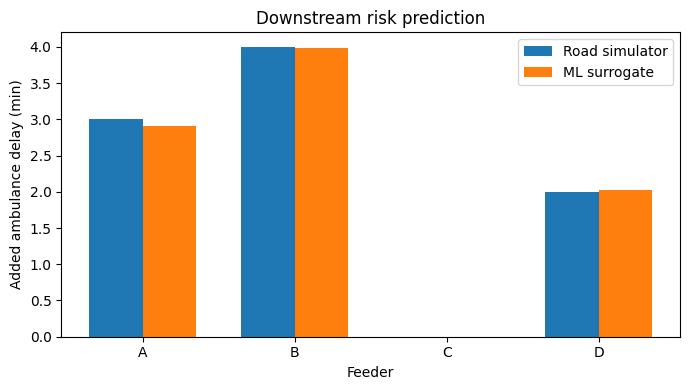

In [15]:
true_current_risk = []

for feeder in feeders:
    graph_i = build_scenario_graph(
        shed_set={feeder},
        degradation_multiplier=current_degradation,
        traffic_factor=current_traffic,
        backup_health=current_backup_health
    )
    added_delay = (
        ambulance_route(graph_i)["total_time"]
        - baseline_route["total_time"]
    )
    true_current_risk.append(added_delay)

fig, ax = plt.subplots(figsize=(7, 4))

x = np.arange(len(feeders))
width = 0.35

ax.bar(x - width / 2, true_current_risk, width, label="Road simulator")
ax.bar(x + width / 2, predicted_risk, width, label="ML surrogate")

ax.set_xticks(x, feeders)
ax.set_xlabel("Feeder")
ax.set_ylabel("Added ambulance delay (min)")
ax.set_title("Downstream risk prediction")
ax.legend()

fig.tight_layout()
plt.show()


## 13. Ambulance route before vs after shedding

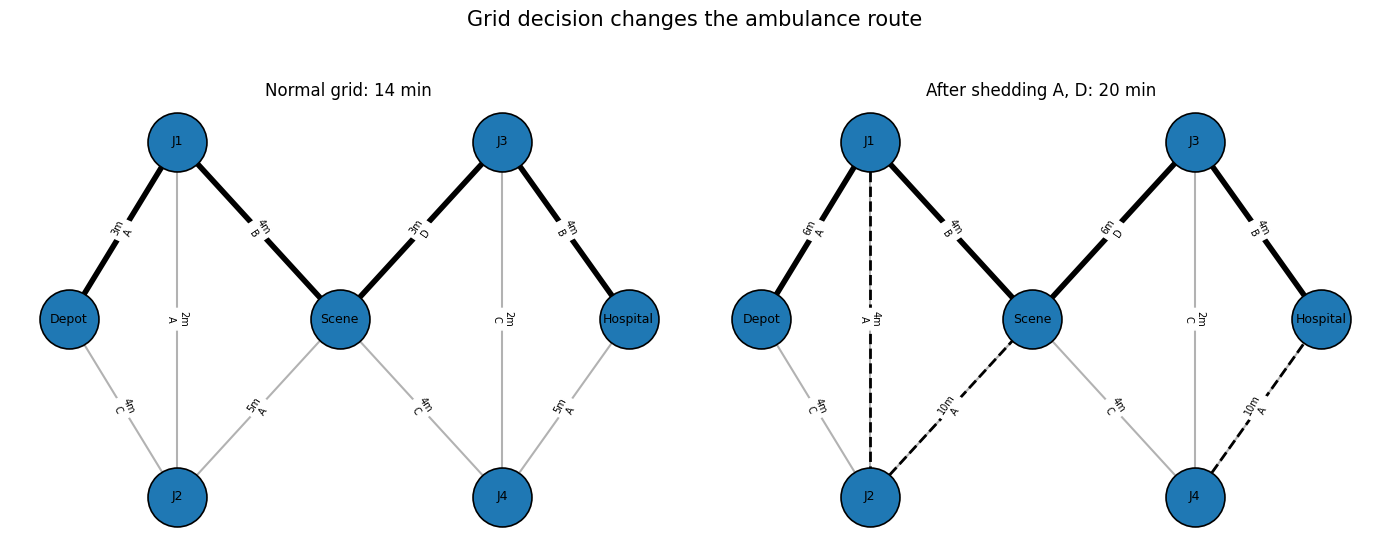

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

plots = [
    (axes[0], baseline_graph, baseline_route, f"Normal grid: {baseline_route['total_time']:.0f} min"),
    (axes[1], degraded_graph, degraded_route, f"After shedding {selected(selected_solution)}: {degraded_route['total_time']:.0f} min")
]

for ax, graph, route_result, title in plots:
    route_edges = list(zip(route_result["full_path"][:-1], route_result["full_path"][1:]))
    nx.draw_networkx_nodes(graph, road_positions, ax=ax, node_size=1800, edgecolors="black", linewidths=1.2)
    nx.draw_networkx_labels(graph, road_positions, ax=ax, font_size=9)
    all_edges = list(graph.edges())
    non_route_edges = [edge for edge in all_edges if edge not in route_edges and (edge[1], edge[0]) not in route_edges]
    nx.draw_networkx_edges(graph, road_positions, ax=ax, edgelist=non_route_edges, width=1.5, alpha=0.3)
    nx.draw_networkx_edges(graph, road_positions, ax=ax, edgelist=route_edges, width=4)
    degraded_edges = [(u, v) for u, v, data in graph.edges(data=True) if data.get("degraded", False)]
    nx.draw_networkx_edges(graph, road_positions, ax=ax, edgelist=degraded_edges, style="dashed", width=2.0)
    edge_labels = {(u, v): f"{data['travel_time']:.0f}m\n{data['feeder']}" for u, v, data in graph.edges(data=True)}
    nx.draw_networkx_edge_labels(graph, road_positions, ax=ax, edge_labels=edge_labels, font_size=7)
    ax.set_title(title)
    ax.axis("off")

fig.suptitle("Grid decision changes the ambulance route", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


## 14. Final prototype summary

In [17]:

summary = pd.DataFrame([
    {
        "Metric": "ML test MAE",
        "Value": f"{mae:.2f} min"
    },
    {
        "Metric": "ML test R²",
        "Value": f"{r2:.3f}"
    },
    {
        "Metric": "Selected feeders",
        "Value": selected(
            selected_solution
        )
    },
    {
        "Metric": "Load shed",
        "Value": (
            f"{shed_load(selected_solution):.0f} MW"
        )
    },
    {
        "Metric": "Target load",
        "Value": f"{target_mw:.0f} MW"
    },
    {
        "Metric": "Baseline ambulance journey",
        "Value": (
            f"{baseline_route['total_time']:.0f} min"
        )
    },
    {
        "Metric": "Post-shedding journey",
        "Value": (
            f"{degraded_route['total_time']:.0f} min"
        )
    },
    {
        "Metric": "Added ambulance delay",
        "Value": f"{added_delay:.0f} min"
    }
])

summary


,Metric,Value
0,ML test MAE,0.15 min
1,ML test R²,0.971
2,Selected feeders,"A, D"
3,Load shed,50 MW
4,Target load,50 MW
5,Baseline ambulance journey,14 min
6,Post-shedding journey,20 min
7,Added ambulance delay,2 min
